In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from scipy.stats import bartlett, gaussian_kde, shapiro, probplot

In [114]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df = df.sample(n=30000, random_state=42)

print(f"Размер датасета: {df.shape}")
print(f"Количество признаков: {df.shape[1] - 1}")  # минус целевая переменная
print(f"Количество объектов: {df.shape[0]}\n")
df.info()

Размер датасета: (30000, 22)
Количество признаков: 21
Количество объектов: 30000

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 219620 to 29091
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_012          30000 non-null  float64
 1   HighBP                30000 non-null  float64
 2   HighChol              30000 non-null  float64
 3   CholCheck             30000 non-null  float64
 4   BMI                   30000 non-null  float64
 5   Smoker                30000 non-null  float64
 6   Stroke                30000 non-null  float64
 7   HeartDiseaseorAttack  30000 non-null  float64
 8   PhysActivity          30000 non-null  float64
 9   Fruits                30000 non-null  float64
 10  Veggies               30000 non-null  float64
 11  HvyAlcoholConsump     30000 non-null  float64
 12  AnyHealthcare         30000 non-null  float64
 13  NoDocbcCost           30000 non-null  f

In [115]:
print('Дескриптивный анализ')
display(df.describe().T)

Дескриптивный анализ


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,30000.0,0.290367,0.691474,0.0,0.0,0.0,0.0,2.0
HighBP,30000.0,0.433467,0.495562,0.0,0.0,0.0,1.0,1.0
HighChol,30000.0,0.426133,0.494522,0.0,0.0,0.0,1.0,1.0
CholCheck,30000.0,0.962433,0.190149,0.0,1.0,1.0,1.0,1.0
BMI,30000.0,28.443900,6.584023,12.0,24.0,27.0,31.0,95.0
Smoker,30000.0,0.444000,0.496862,0.0,0.0,0.0,1.0,1.0
Stroke,30000.0,0.039600,0.195021,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,30000.0,0.093667,0.291369,0.0,0.0,0.0,0.0,1.0
PhysActivity,30000.0,0.757167,0.428802,0.0,1.0,1.0,1.0,1.0
Fruits,30000.0,0.632867,0.482031,0.0,0.0,1.0,1.0,1.0


In [116]:
bools = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
                                   'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
                                   'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                                   'NoDocbcCost', 'DiffWalk', 'Sex']
cats = ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

target_feature = df[['Diabetes_012']].columns
all_features = df.columns.drop(target_feature)
bool_feat = df[bools].columns
features = all_features.drop(bool_feat)
cats_feat = df[cats].columns

Нормальность распределения признаков


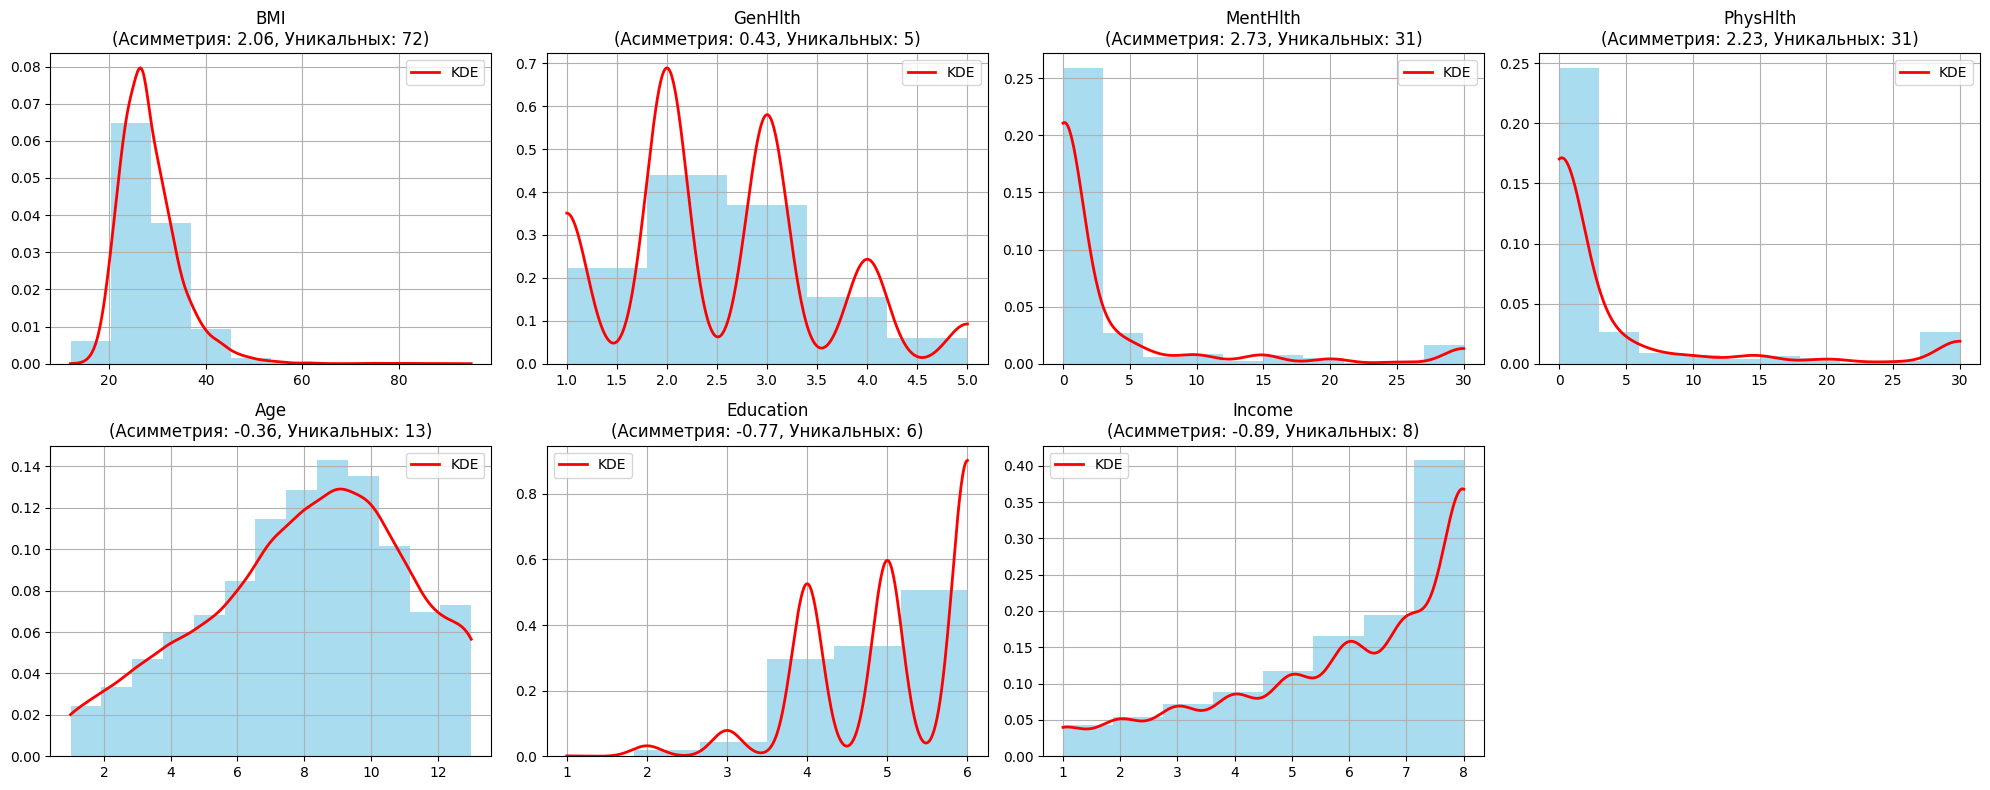

In [117]:
print("Нормальность распределения признаков")

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    data = df[feature].dropna()
    
    n_unique = data.nunique()
    is_discrete = n_unique <= 20
    
    if is_discrete:
        data.hist(ax=axes[i], alpha=0.7, color='skyblue', density=True, bins=n_unique)
    else:
        data.hist(ax=axes[i], alpha=0.7, color='skyblue', density=True)
    
    kde = gaussian_kde(data)
    kde.set_bandwidth(kde.factor * 1.5)
    
    x_range = np.linspace(data.min(), data.max(), 500)
    axes[i].plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    axes[i].set_title(f'{feature}\n(Асимметрия: {data.skew():.2f}, Уникальных: {n_unique})')
    axes[i].set_xlabel('')
    axes[i].legend()
    
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [125]:
normality_results = []

print('Расчет критерия Шапиро-Уилка')
for feature in all_features:
    stat, p_value = shapiro(df[feature][:5000])
    normality_results.append({
        'Признак': feature,
        'Статистика': stat.round(5),
        'p-value': p_value.round(5),
        'Нормальное': p_value > 0.05
    })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

normal_count = normality_df['Нормальное'].sum()
total_count = len(normality_df)
print(f"\n📊 Результат: {normal_count}/{total_count} признаков имеют нормальное распределение")

Расчет критерия Шапиро-Уилка


,Признак,Статистика,p-value,Нормальное
0,HighBP,0.62987,0.0,False
1,HighChol,0.62817,0.0,False
2,CholCheck,0.18616,0.0,False
3,BMI,0.88624,0.0,False
4,Smoker,0.63265,0.0,False
5,Stroke,0.19075,0.0,False
6,HeartDiseaseorAttack,0.33625,0.0,False
7,PhysActivity,0.53805,0.0,False
8,Fruits,0.60982,0.0,False
9,Veggies,0.48559,0.0,False



📊 Результат: 0/21 признаков имеют нормальное распределение


📐 Q-Q PLOTS ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ:


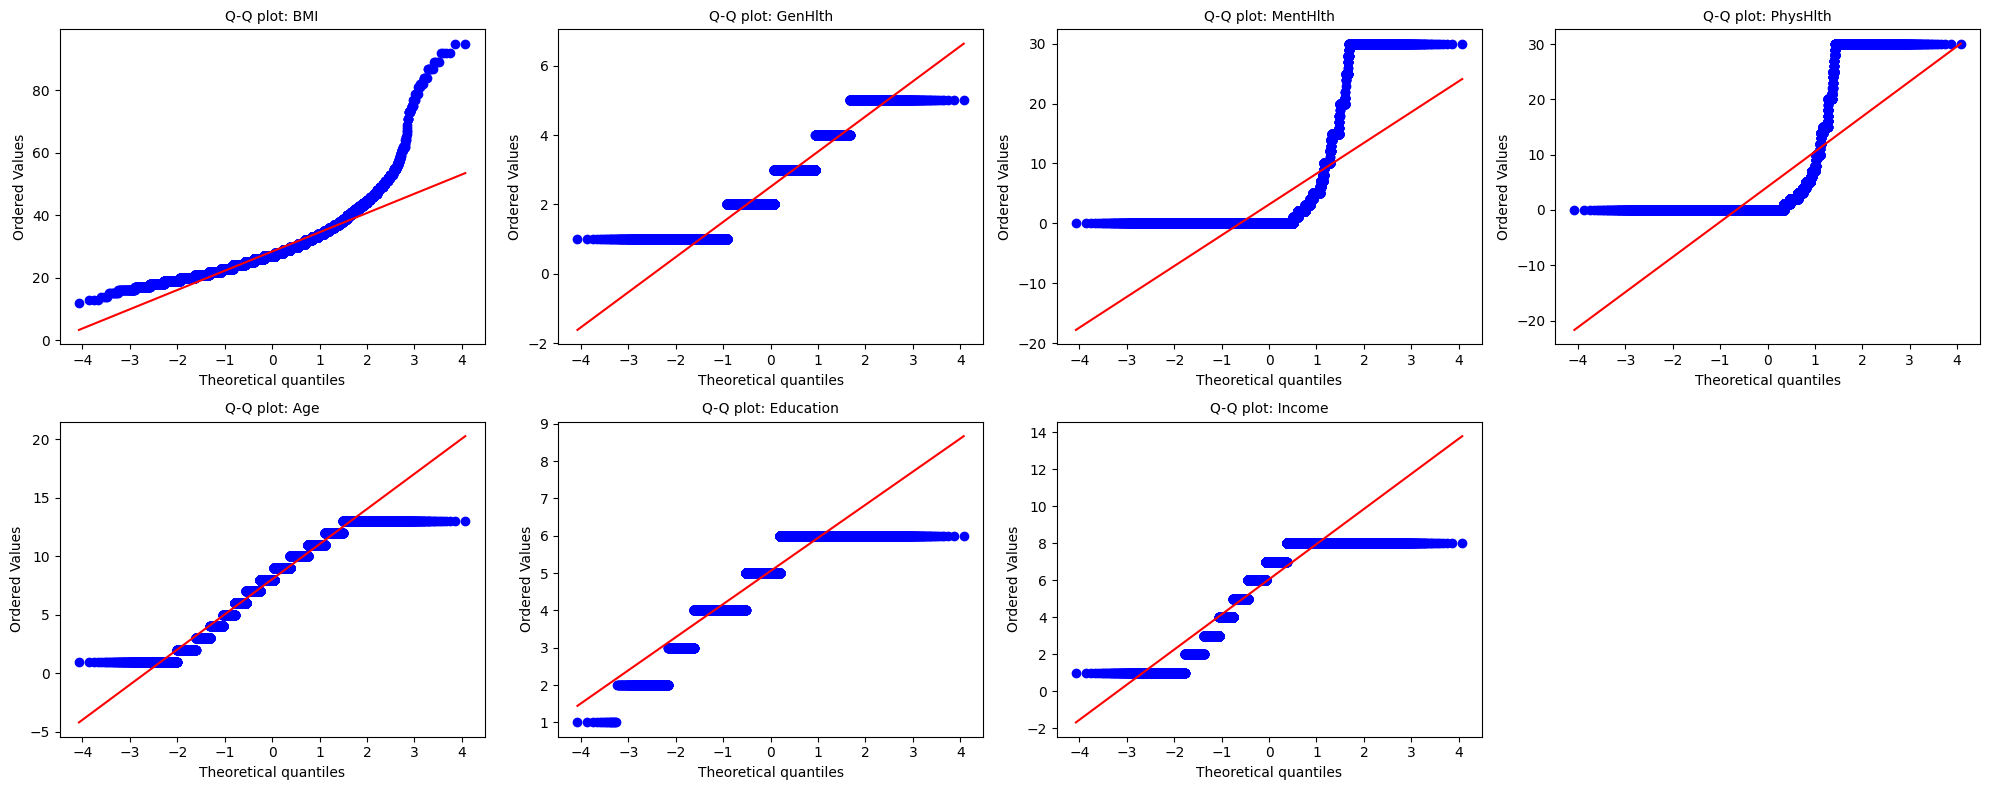

In [126]:
# Q-Q plots для детальной проверки нормальности
print("📐 Q-Q PLOTS ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ:")

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q plot: {feature}', fontsize=10)

# Скрываем пустые subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

🔗 МАТРИЦА КОРРЕЛЯЦИЙ ТОП-ПРИЗНАКОВ


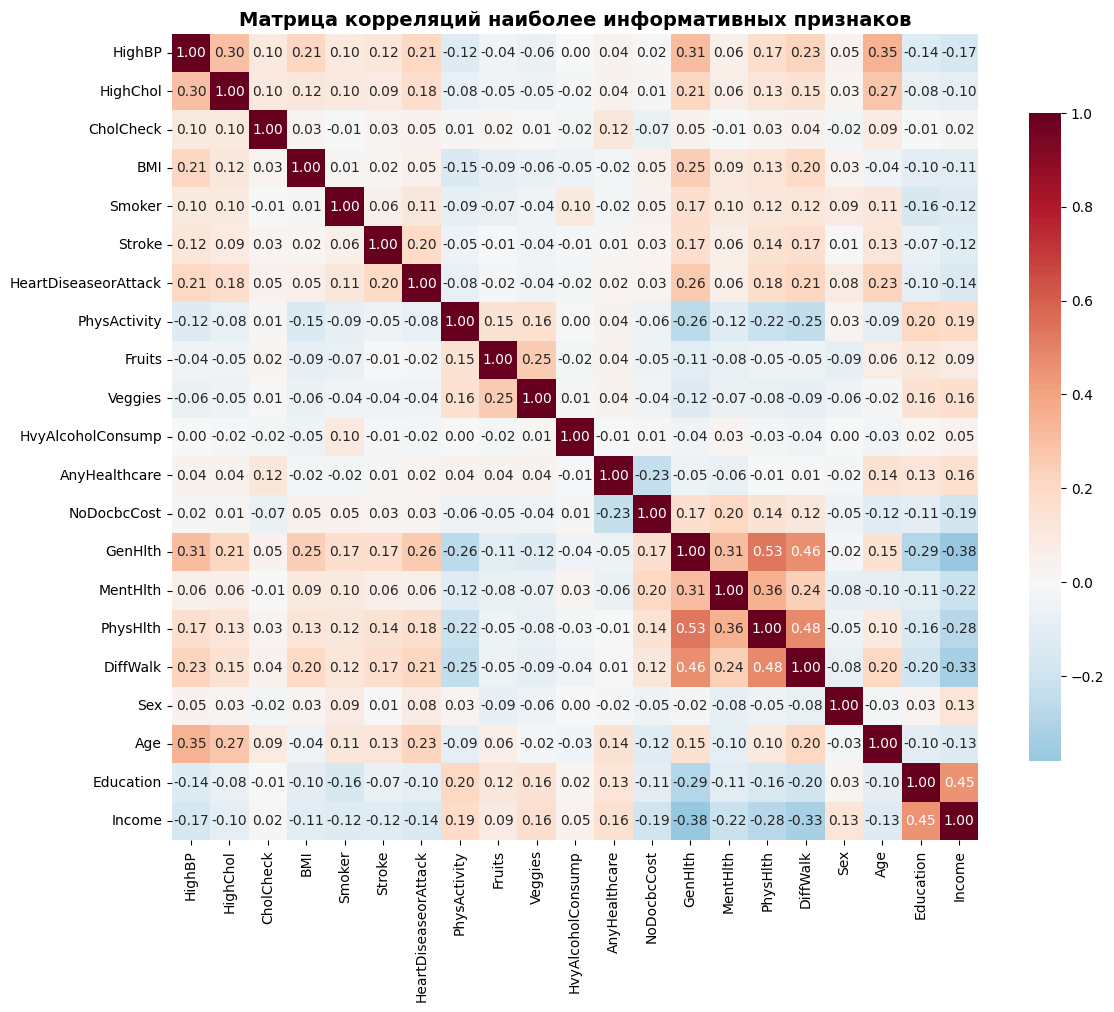

In [127]:
# Матрица корреляций
print("🔗 МАТРИЦА КОРРЕЛЯЦИЙ ТОП-ПРИЗНАКОВ")

plt.figure(figsize=(12, 10))
corr_matrix = df.drop(target_feature, axis=1).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmax=1,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций наиболее информативных признаков', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

На матрице корреляций можно наблюдать кластер корреляций между общим показателем здоровья GenHlth, показателем ментального здоровья MentHlth, физического здоровья PhysHlth и DiffWalk. Также все эти показатели имеют обратную корреляцию от уровня заработка Income. Это можно охарактеризовать как фактор общего здоровья.
Помимо этого, можно наблюдать фактор зависимости высокого давления HighBP и холестерина HighChol от возраста Age и BMI и их влияния на GenHlth.
Есть небольшая корреляция между физической активностью PhysActivity и потреблением овощей и фруктов Veggies и Fruits (фактор здорового образа жизни).

In [128]:
scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[all_features] = scaler.fit_transform(df[all_features])

print("📊 СТАТИСТИКИ ПОСЛЕ СТАНДАРТИЗАЦИИ:")
display(df_scaled.describe().round(5))

📊 СТАТИСТИКИ ПОСЛЕ СТАНДАРТИЗАЦИИ:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,...,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000,30000.00000
mean,0.29037,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00000,0.00000,0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,-0.00000
std,0.69147,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,...,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002,1.00002
min,0.00000,-0.87471,-0.86172,-5.06156,-2.49759,-0.89362,-0.20306,-0.32148,-1.76580,-1.31294,...,-4.38356,-0.30204,-1.41153,-0.42928,-0.48241,-0.44920,-0.88797,-2.29966,-4.14660,-2.45084
25%,0.00000,-0.87471,-0.86172,0.19757,-0.67496,-0.89362,-0.20306,-0.32148,0.56632,-1.31294,...,0.22812,-0.30204,-0.47571,-0.42928,-0.48241,-0.44920,-0.88797,-0.66415,-1.07883,-0.51356
50%,0.00000,-0.87471,-0.86172,0.19757,-0.21931,-0.89362,-0.20306,-0.32148,0.56632,0.76165,...,0.22812,-0.30204,-0.47571,-0.42928,-0.48241,-0.44920,-0.88797,-0.00994,-0.05624,0.45508
75%,0.00000,1.14323,1.16047,0.19757,0.38823,1.11904,-0.20306,-0.32148,0.56632,0.76165,...,0.22812,-0.30204,0.46011,-0.15758,-0.13726,-0.44920,1.12617,0.64426,0.96635,0.93940
max,2.00000,1.14323,1.16047,0.19757,10.10890,1.11904,4.92469,3.11065,0.56632,0.76165,...,0.22812,3.31085,2.33175,3.64626,2.96908,2.22619,1.12617,1.62557,0.96635,0.93940


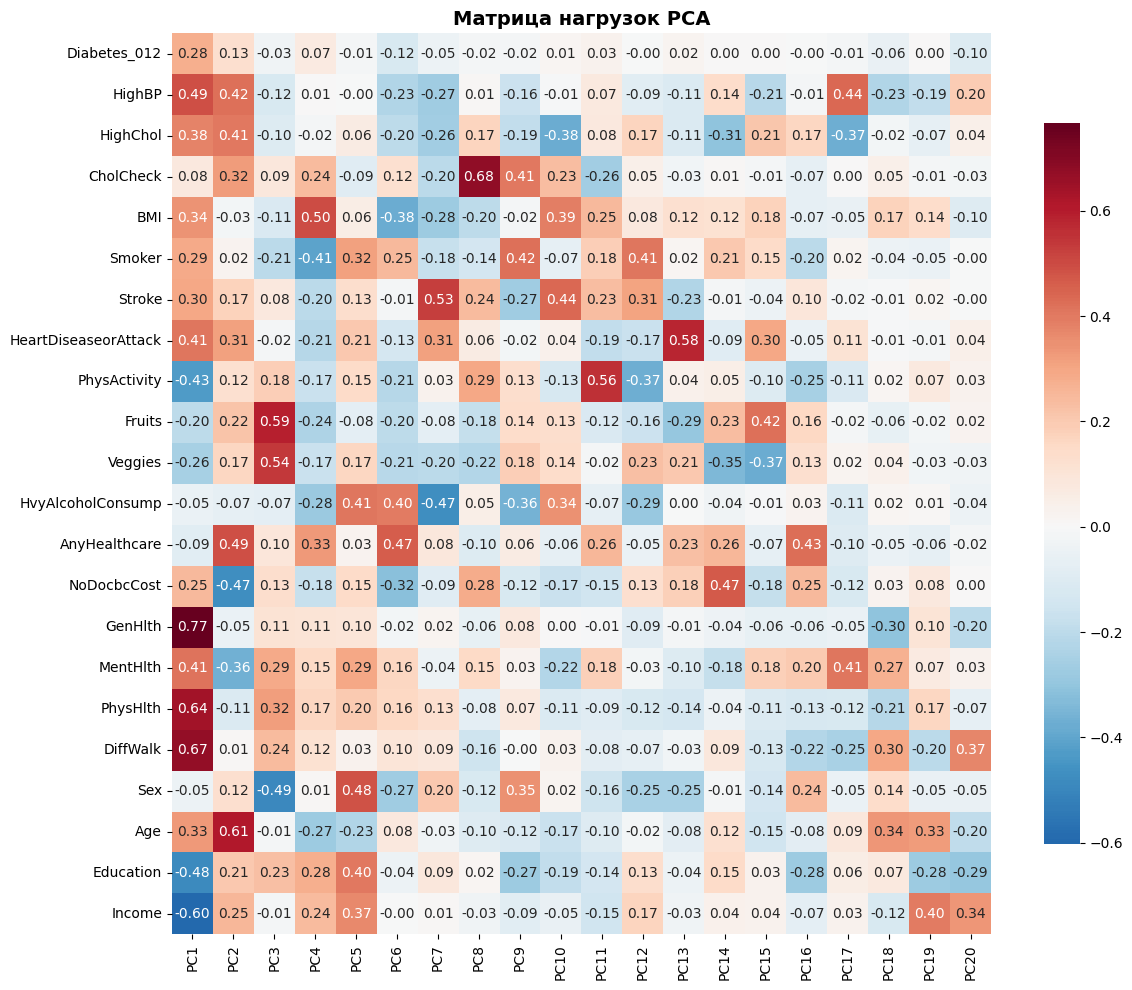

In [129]:
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
pca_result = pca.fit_transform(df_scaled)

# Собственные значения и объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Матрица нагрузок для PCA
pca_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df_pca = pd.DataFrame(pca_loadings, 
                              index=df_scaled.columns,
                              columns=[f'PC{i+1}' for i in range(len(pca.components_))])
# display(loadings_df_pca.round(3))

plt.figure(figsize=(12, 10))

sns.heatmap(loadings_df_pca.round(3), annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})

plt.title('Матрица нагрузок PCA', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

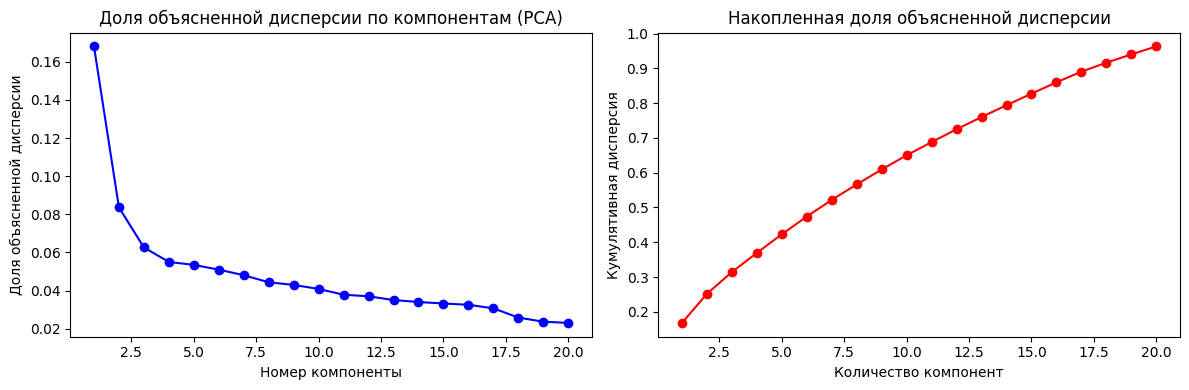

In [130]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Доля объясненной дисперсии по компонентам (PCA)')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная дисперсия')
plt.title('Накопленная доля объясненной дисперсии')

plt.tight_layout()
plt.show()